# Random Forest 

Implementaremos um modelo inicial de Random Forest, a fim de buscar uma maneira de classificação dos nossos dados de maneira automática

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, random, sklearn
import tensorflow as tf
import scipy.stats as stats
import keras_tuner as kt
from scipy.stats import kurtosis
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tqdm import tqdm

sns.set_theme(style="whitegrid")
%matplotlib inline

=== Executando Validação Cruzada por Grupos ===
Fold 1 - Acurácia: 0.9923
Fold 2 - Acurácia: 0.9821
Fold 3 - Acurácia: 0.9974
Fold 4 - Acurácia: 0.9923
Fold 5 - Acurácia: 0.9744

ACURÁCIA MÉDIA REAL DO MODELO: 0.9877 (98.77%)

=== Relatório de Classificação Geral ===
                         precision    recall  f1-score   support

                 normal       0.98      0.94      0.96        49
              imbalance       1.00      0.98      0.99       333
horizontal-misalignment       0.97      0.96      0.97       197
  vertical-misalignment       0.97      0.98      0.98       301
              underhang       0.99      1.00      0.99       558
               overhang       0.99      1.00      1.00       513

               accuracy                           0.99      1951
              macro avg       0.98      0.98      0.98      1951
           weighted avg       0.99      0.99      0.99      1951



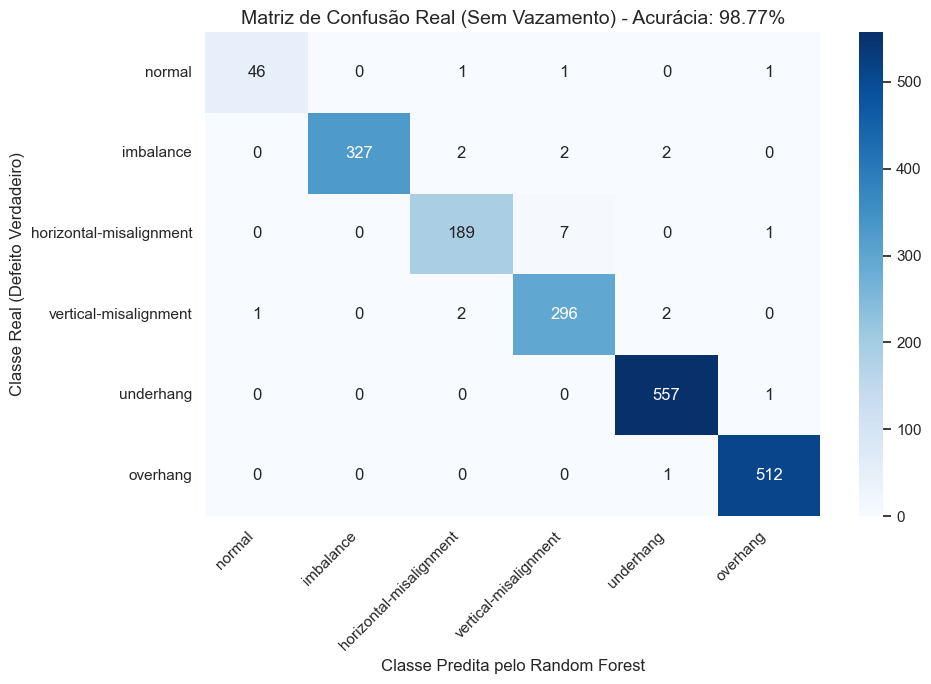

In [3]:
# Carrega os dados processados
df = pd.read_csv("mafaulda_pronto_para_modelo.csv")

df["grupo_unico"] = df["class_name"] + "_" + df["source_file"]

scaler = StandardScaler()

# Separa as variáveis, alvos e os grupos atualizados
X = df.drop(columns=["target", "class_name", "source_file"])

# Se criou a coluna temporária acima, remove do X também:
if "grupo_unico" in X.columns:
    X = X.drop(columns=["grupo_unico"])
y = df["target"]
grupos = df["source_file"]  # Evita o vazamento de dados

# Guarda os nomes das classes para o gráfico
nomes_classes = df.sort_values("target")["class_name"].unique()

# Configura a Validação Cruzada por Grupos (5 Folds)
gkf = GroupKFold(n_splits=5)

# Lista para acumular as respostas reais e as previsões de todos os folds
todas_respostas_reais = []
todas_previsoes = []
acuracias_folds = []

print("=== Executando Validação Cruzada por Grupos ===")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=grupos)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Inicializa e treina o Random Forest
    modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    modelo_rf.fit(X_train, y_train)
    
    # Faz as predições para o teste atual
    y_pred = modelo_rf.predict(X_test)
    
    # Salva os resultados para a avaliação
    todas_respostas_reais.extend(y_test)
    todas_previsoes.extend(y_pred)
    
    # Calcula a acurácia específica
    acc_fold = accuracy_score(y_test, y_pred)
    acuracias_folds.append(acc_fold)
    print(f"Fold {fold + 1} - Acurácia: {acc_fold:.4f}")

# Ajusta o scaler no treino e transforma ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cálculo das Métricas Finais Globais
acuracia_final = accuracy_score(todas_respostas_reais, todas_previsoes)
print(f"\n==========================================")
print(f"ACURÁCIA MÉDIA REAL DO MODELO: {acuracia_final:.4f} ({acuracia_final*100:.2f}%)")
print(f"==========================================\n")

print("=== Relatório de Classificação Geral ===")
print(classification_report(todas_respostas_reais, todas_previsoes, target_names=nomes_classes))

# Gera e Plota a Matriz de Confusão
cm = confusion_matrix(todas_respostas_reais, todas_previsoes)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nomes_classes, 
    yticklabels=nomes_classes
)
plt.title(f'Matriz de Confusão Real (Sem Vazamento) - Acurácia: {acuracia_final*100:.2f}%', fontsize=14)
plt.ylabel('Classe Real (Defeito Verdadeiro)', fontsize=12)
plt.xlabel('Classe Predita pelo Random Forest', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Random Forest

Agora, implementaremos um modelo de Random Forest com o uso de múltiplas seeds a fim de procurar tirar o fator sorte/azar do jogo

In [4]:
# Recarregamos os dados para que não haja modificações anteriores
df_rf_multi_seed = pd.read_csv("mafaulda_pronto_para_modelo.csv")

df_rf_multi_seed["grupo_unico"] = df_rf_multi_seed["class_name"] + "_" + df_rf_multi_seed["source_file"]

# Separa as variáveis, alvos e os grupos atualizados
X_rf_ms = df_rf_multi_seed.drop(columns=["target", "class_name", "source_file"])

# Se criou a coluna temporária acima, remove
if "grupo_unico" in X_rf_ms.columns:
    X_rf_ms = X_rf_ms.drop(columns=["grupo_unico"])
y_rf_ms = df_rf_multi_seed["target"]
grupos_rf_ms = df_rf_multi_seed["source_file"]

# Guarda os nomes das classes
nomes_classes_rf_ms = df_rf_multi_seed.sort_values("target")["class_name"].unique()

# Lista de seeds para testar
lista_seeds = [42, 123, 7, 99, 101, 200, 300, 400, 500]

melhor_acuracia_geral_rf = -1
melhor_seed_rf = None

# Variáveis para armazenar o X_train_scaled, X_test_scaled, y_train, y_test da melhor seed
X_train_scaled_melhor_seed = None
X_test_scaled_melhor_seed = None
y_train_melhor_seed = None
y_test_melhor_seed = None

# Loop para testar múltiplas seeds
for seed_atual in lista_seeds:
    print(f"\n=== Executando Validação Cruzada por Grupos com Seed: {seed_atual} ===")

    # Configura a Validação Cruzada por Grupos (5 Folds)
    gkf_ms = GroupKFold(n_splits=5)

    # Lista para acumular as respostas reais e as previsões de todos os folds para esta seed
    todas_respostas_reais_seed = []
    todas_previsoes_seed = []
    
    # Inicializa o scaler para cada seed
    scaler_ms = StandardScaler()

    for fold, (train_idx, test_idx) in enumerate(gkf_ms.split(X_rf_ms, y_rf_ms, groups=grupos_rf_ms)):
        X_train_ms, X_test_ms = X_rf_ms.iloc[train_idx], X_rf_ms.iloc[test_idx]
        y_train_ms, y_test_ms = y_rf_ms.iloc[train_idx], y_rf_ms.iloc[test_idx]
        
        # Escalonamento dos dados dentro do loop de validação cruzada (evitar avazamentos)
        X_train_scaled_ms = scaler_ms.fit_transform(X_train_ms)
        X_test_scaled_ms = scaler_ms.transform(X_test_ms)

        # Inicializa e treina o Random Forest com a seed atual
        modelo_rf_ms = RandomForestClassifier(n_estimators=100, random_state=seed_atual, n_jobs=-1)
        modelo_rf_ms.fit(X_train_scaled_ms, y_train_ms)

        # Faz as predições para o teste atual
        y_pred_ms = modelo_rf_ms.predict(X_test_scaled_ms)

        # Salva os resultados para a avaliação
        todas_respostas_reais_seed.extend(y_test_ms)
        todas_previsoes_seed.extend(y_pred_ms)

        # Calcula a acurácia específica do fold
        acc_fold_ms = accuracy_score(y_test_ms, y_pred_ms)
        print(f"Fold {fold + 1} - Acurácia: {acc_fold_ms:.4f}")

    # Cálculo das Métricas Finais Globais para a seed atual
    acuracia_geral_seed_atual = accuracy_score(todas_respostas_reais_seed, todas_previsoes_seed)
    print(f"\nACURÁCIA GERAL PARA SEED {seed_atual}: {acuracia_geral_seed_atual:.4f} ({acuracia_geral_seed_atual*100:.2f}%) --------")

    if acuracia_geral_seed_atual > melhor_acuracia_geral_rf:
        melhor_acuracia_geral_rf = acuracia_geral_seed_atual
        melhor_seed_rf = seed_atual
        # Armazena o último split escalado da melhor seed
        X_train_scaled_melhor_seed = X_train_scaled_ms.copy()
        X_test_scaled_melhor_seed = X_test_scaled_ms.copy()
        y_train_melhor_seed = y_train_ms.copy()
        y_test_melhor_seed = y_test_ms.copy()

print(f"\n==========================================")
print(f"MELHOR SEED ENCONTRADA PARA RANDOM FOREST: {melhor_seed_rf}")
print(f"MELHOR ACURÁCIA GERAL COM ESSA SEED: {melhor_acuracia_geral_rf:.4f} ({melhor_acuracia_geral_rf*100:.2f}%)")
print(f"==========================================\n")

# As variáveis X_train_scaled, X_test_scaled, y_train, y_test serão atualizadas para serem usadas pela Rede Neural
# com base no último split da melhor seed do Random Forest.
X_train_scaled = X_train_scaled_melhor_seed
X_test_scaled = X_test_scaled_melhor_seed
y_train = y_train_melhor_seed
y_test = y_test_melhor_seed

print("Variáveis de treino/teste (X_train_scaled, X_test_scaled, y_train, y_test) atualizadas com a melhor seed do Random Forest.")


=== Executando Validação Cruzada por Grupos com Seed: 42 ===
Fold 1 - Acurácia: 0.9923
Fold 2 - Acurácia: 0.9821
Fold 3 - Acurácia: 0.9974
Fold 4 - Acurácia: 0.9923
Fold 5 - Acurácia: 0.9744

ACURÁCIA GERAL PARA SEED 42: 0.9877 (98.77%) --------

=== Executando Validação Cruzada por Grupos com Seed: 123 ===
Fold 1 - Acurácia: 0.9847
Fold 2 - Acurácia: 0.9846
Fold 3 - Acurácia: 1.0000
Fold 4 - Acurácia: 0.9897
Fold 5 - Acurácia: 0.9744

ACURÁCIA GERAL PARA SEED 123: 0.9867 (98.67%) --------

=== Executando Validação Cruzada por Grupos com Seed: 7 ===
Fold 1 - Acurácia: 0.9898
Fold 2 - Acurácia: 0.9897
Fold 3 - Acurácia: 0.9974
Fold 4 - Acurácia: 0.9949
Fold 5 - Acurácia: 0.9769

ACURÁCIA GERAL PARA SEED 7: 0.9897 (98.97%) --------

=== Executando Validação Cruzada por Grupos com Seed: 99 ===
Fold 1 - Acurácia: 0.9872
Fold 2 - Acurácia: 0.9821
Fold 3 - Acurácia: 0.9974
Fold 4 - Acurácia: 0.9897
Fold 5 - Acurácia: 0.9744

ACURÁCIA GERAL PARA SEED 99: 0.9862 (98.62%) --------

=== Executa

In [5]:
# Salva os dados da melhor seed para usar nas Redes Neurais
# Cria um diretório para salvar os dados
os.makedirs("dados_treino_teste_best_rf_seed", exist_ok=True)
np.save("dados_treino_teste_best_rf_seed/X_train_scaled_best_rf.npy", X_train_scaled_melhor_seed)
np.save("dados_treino_teste_best_rf_seed/X_test_scaled_best_rf.npy", X_test_scaled_melhor_seed)
np.save("dados_treino_teste_best_rf_seed/y_train_best_rf.npy", y_train_melhor_seed)
np.save("dados_treino_teste_best_rf_seed/y_test_best_rf.npy", y_test_melhor_seed)

# Salve os nomes das classes
np.save("dados_treino_teste_best_rf_seed/nomes_classes_rf_ms.npy", nomes_classes_rf_ms)
print("Variáveis de treino/teste (escaladas da melhor seed do Random Forest) salvas com sucesso.")

Variáveis de treino/teste (escaladas da melhor seed do Random Forest) salvas com sucesso.


=== Relatório de Classificação Geral (Melhor Seed do Random Forest) ===
                         precision    recall  f1-score   support

                 normal       1.00      1.00      1.00         9
              imbalance       1.00      0.95      0.97        55
horizontal-misalignment       0.95      0.91      0.93        46
  vertical-misalignment       0.94      0.97      0.95        62
              underhang       0.97      1.00      0.99       109
               overhang       1.00      1.00      1.00       109

               accuracy                           0.98       390
              macro avg       0.98      0.97      0.97       390
           weighted avg       0.98      0.98      0.98       390



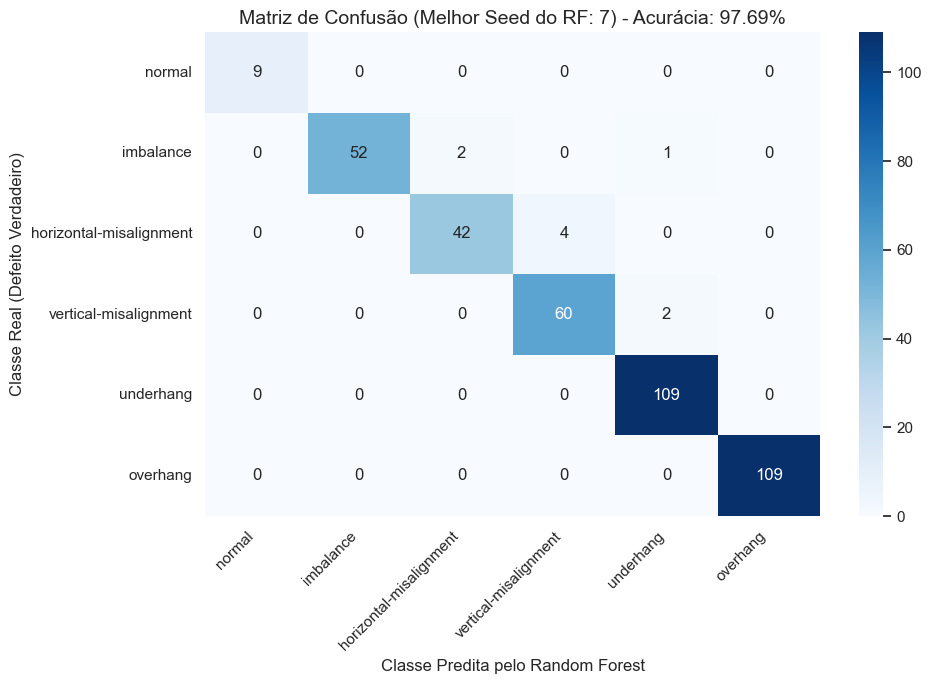

In [6]:
# Re-treina o modelo Random Forest com a melhor seed no último split salvo para gerar o relatório final
modelo_rf_final_best_seed = RandomForestClassifier(n_estimators=100, random_state=melhor_seed_rf, n_jobs=-1)
modelo_rf_final_best_seed.fit(X_train_scaled, y_train)
y_pred_final_best_seed = modelo_rf_final_best_seed.predict(X_test_scaled)

print("=== Relatório de Classificação Geral (Melhor Seed do Random Forest) ===")
print(classification_report(y_test, y_pred_final_best_seed, target_names=nomes_classes_rf_ms))

# Gera e Plota a Matriz de Confusão com os dados da melhor seed
cm_best_seed = confusion_matrix(y_test, y_pred_final_best_seed)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_best_seed,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_classes_rf_ms,
    yticklabels=nomes_classes_rf_ms
)
plt.title(f'Matriz de Confusão (Melhor Seed do RF: {melhor_seed_rf}) - Acurácia: {accuracy_score(y_test, y_pred_final_best_seed)*100:.2f}%', fontsize=14)
plt.ylabel('Classe Real (Defeito Verdadeiro)', fontsize=12)
plt.xlabel('Classe Predita pelo Random Forest', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()